# Turtle Draw - Robótica e Visão computacional
Este projeto une técnicas de visão computacional para leitura, processamento e detecção de bordas de uma imagem. Para que seja possível coletar as cordenadas do contorno da imagem que, posteriormente, serão enviadas por meio do midleware ROS2, para gerar o desenho do contorno na Turtlesim.

## 1. Pré-processamento
Nesta etapa será realizada as etapas de pré-processamento da imagem, visando garantir uma imagem tratada para que o processo de detecção de bordas seja mais eficiente e preciso.

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

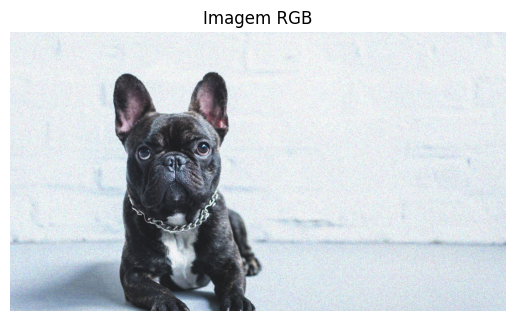

In [2]:
# ler a imagem - BGR
img_bgr = cv.imread('dog.jpg')

# Transforma em RGB
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Mostrar a imagem
plt.imshow(img_rgb)
plt.title("Imagem RGB")
plt.axis("off")
plt.show()

### 1.1. Conversão em Tons de Cinza (Grayscale)

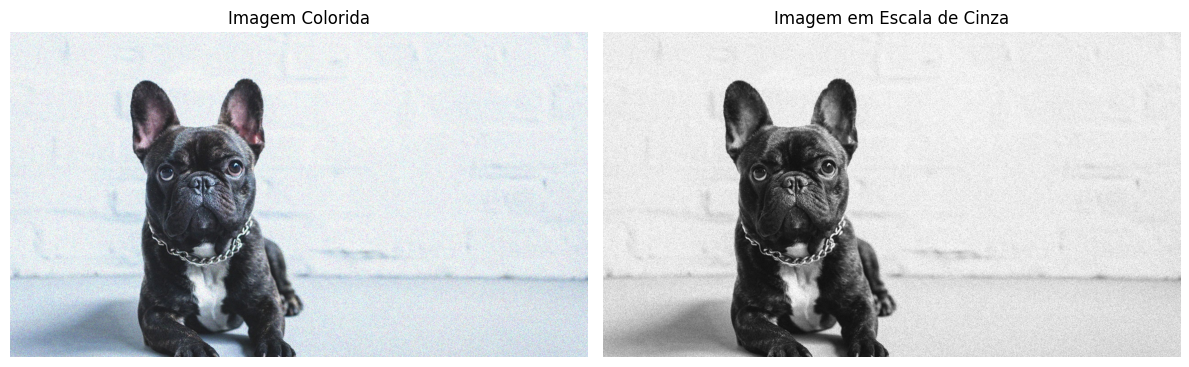

In [3]:
# Converte a imagem para um array NumPy
img_array = np.array(img_rgb)

# Grayscale formula: Y = 0.299*R + 0.587*G + 0.114*B
gray_img = np.dot(img_array[..., :3], [0.299, 0.587, 0.114])

# Mostra as imagens lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Imagem Colorida')
axes[0].axis('off')
axes[1].imshow(gray_img, cmap='gray')
axes[1].set_title('Imagem em Escala de Cinza')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 1.2. Suavização
Para a suavização foi usado um filtro Gaussiano, que ajuda a reduzir o ruído e os detalhes da imagem usando um kernel gaussiano.

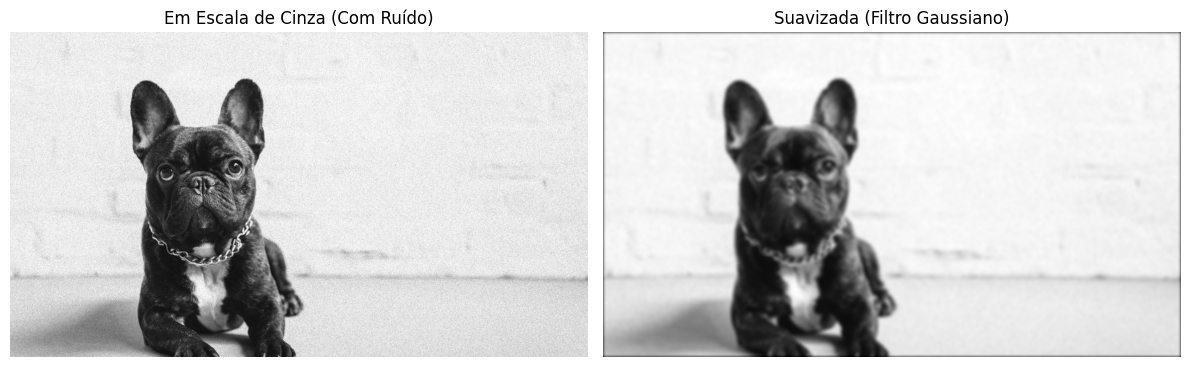

In [4]:
# Kernel Gaussiano 15x15 para Limpeza de Texturas
kernel = np.array([
    [2,  3,  5,  6,  7,  8,  8,  8,  8,  8,  7,  6,  5,  3, 2],
    [3,  5,  8, 11, 13, 14, 15, 15, 15, 14, 13, 11,  8,  5, 3],
    [5,  8, 13, 18, 22, 24, 26, 26, 26, 24, 22, 18, 13,  8, 5],
    [6, 11, 18, 26, 33, 37, 39, 40, 39, 37, 33, 26, 18, 11, 6],
    [7, 13, 22, 33, 43, 49, 52, 53, 52, 49, 43, 33, 22, 13, 7],
    [8, 14, 24, 37, 49, 57, 61, 62, 61, 57, 49, 37, 24, 14, 8],
    [8, 15, 26, 39, 52, 61, 66, 67, 66, 61, 52, 39, 26, 15, 8],
    [8, 15, 26, 40, 53, 62, 67, 68, 67, 62, 53, 40, 26, 15, 8],
    [8, 15, 26, 39, 52, 61, 66, 67, 66, 61, 52, 39, 26, 15, 8],
    [8, 14, 24, 37, 49, 57, 61, 62, 61, 57, 49, 37, 24, 14, 8],
    [7, 13, 22, 33, 43, 49, 52, 53, 52, 49, 43, 33, 22, 13, 7],
    [6, 11, 18, 26, 33, 37, 39, 40, 39, 37, 33, 26, 18, 11, 6],
    [5,  8, 13, 18, 22, 24, 26, 26, 26, 24, 22, 18, 13,  8, 5],
    [3,  5,  8, 11, 13, 14, 15, 15, 15, 14, 13, 11,  8,  5, 3],
    [2,  3,  5,  6,  7,  8,  8,  8,  8,  8,  7,  6,  5,  3, 2]
], dtype=np.float32)

# Normalização: divide pela soma de todos os elementos da matriz gigante
kernel = kernel / np.sum(kernel)
def convolucao_2d(imagem, kernel):
    # pegar os tamanhos da imagem e do kernel
    altura_img, largura_img = imagem.shape
    altura_kernel, largura_kernel = kernel.shape
    
    # calcular o padding necessário para manter o tamanho da imagem
    pad_h = altura_kernel // 2
    pad_w = largura_kernel // 2
    
    # aplicar o padding na imagem
    img_pad = np.pad(imagem, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    # criar uma imagem de saída com o mesmo tamanho da imagem original - vai ser substituida pelos valores convoluídos
    img_saida = np.zeros_like(imagem)
    
    # aplicar a convolução
    for i in range(altura_img):
        for j in range(largura_img):
            regiao = img_pad[i : i + altura_kernel, j : j + largura_kernel]
            img_saida[i, j] = np.sum(regiao * kernel)
            
    return img_saida

# Aplicando a função 
blurred_img = convolucao_2d(gray_img, kernel)

# Mostra os resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Em Escala de Cinza (Com Ruído)')
axes[0].axis('off')

axes[1].imshow(blurred_img, cmap='gray')
axes[1].set_title('Suavizada (Filtro Gaussiano)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

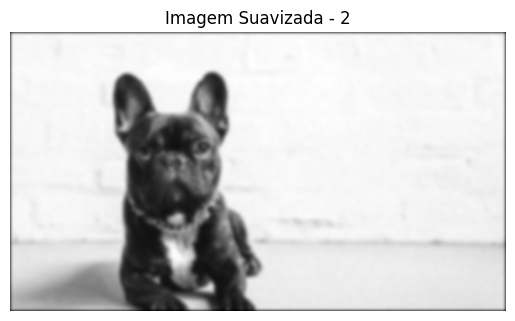

In [5]:
blurred_img2 = convolucao_2d(blurred_img, kernel)

plt.imshow(blurred_img2, cmap='gray')
plt.title("Imagem Suavizada - 2")
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

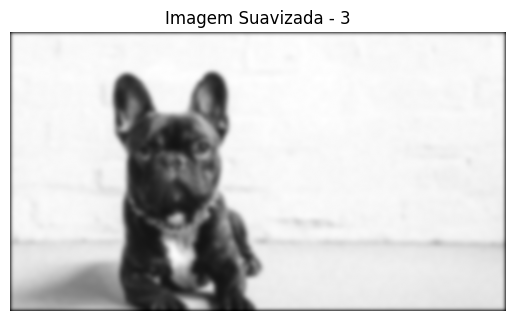

In [6]:
blurred_img3 = convolucao_2d(blurred_img2, kernel)

plt.imshow(blurred_img3, cmap='gray')
plt.title("Imagem Suavizada - 3")
plt.axis("off")

## 2. Detecção de bordas

### 2.1. Algoritimo de Sobel

Dimensões da imagem de bordas: 720x1280


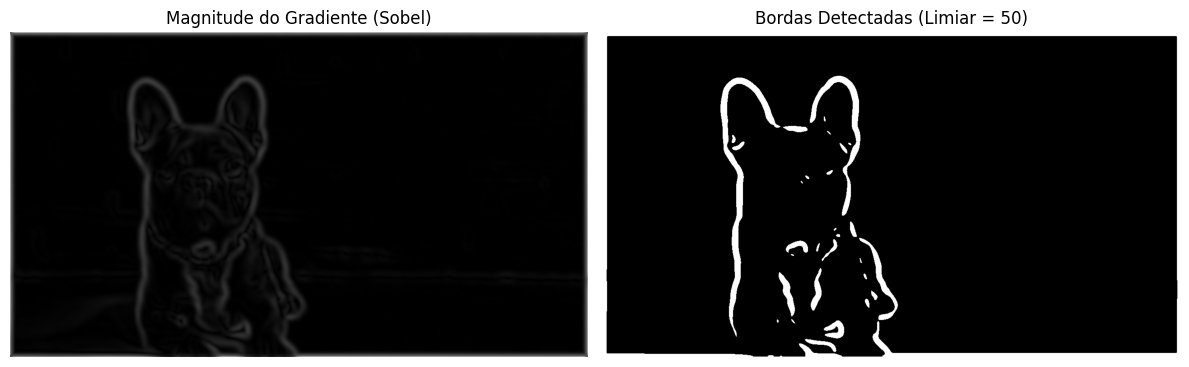

In [7]:
# Kernel de Sobel Padrão 3x3
# Sobel X:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Sobel Y:
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Aplicando a função de convolução com os kernels de Sobel
grau_x = convolucao_2d(blurred_img3, sobel_x)
grau_y = convolucao_2d(blurred_img3, sobel_y)

# Aplicando a magnitude do gradiente para obter a imagem de bordas
magnitude = np.sqrt(grau_x**2 + grau_y**2)

# Limiarização (thresholding)
limiar = 50
bordas = np.where(magnitude > limiar, 255, 0)

largura_img, altura_img = bordas.shape
print(f"Dimensões da imagem de bordas: {largura_img}x{altura_img}")

# Mostra os resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(magnitude, cmap='gray')
axes[0].set_title('Magnitude do Gradiente (Sobel)')
axes[0].axis('off')
axes[1].imshow(bordas, cmap='gray')
axes[1].set_title('Bordas Detectadas (Limiar = 50)')
axes[1].axis('off')
plt.tight_layout()
plt.show() 

## 3. Planejamento de caminho

### 3.1. Extrair pontos do contorno

In [8]:
def extrair_caminho_ordenado(matriz_bordas, largura_img, altura_img, margem_pixels=10):
    """
    Extrai e ordena os pontos das bordas corrigindo o eixo (X, Y) 
    e ignorando a moldura da imagem.
    """
    # 1. Encontra os índices (linha, coluna) -> (Y, X)
    pontos_brutos = np.argwhere(matriz_bordas > 0)
    
    if len(pontos_brutos) == 0:
        return []
    
    pontos_filtrados = []
    
    # 2. SEPARAÇÃO EM (X, Y) E REMOÇÃO DA MOLDURA
    for linha, coluna in pontos_brutos:
        if (margem_pixels < coluna < (largura_img - margem_pixels)) and \
           (margem_pixels < linha < (altura_img - margem_pixels)):
            # Coluna mapeia diretamente para o eixo X horizontal
            # Linha mapeia diretamente para o eixo Y vertical
            pontos_filtrados.append((float(coluna), float(linha)))
            
    if len(pontos_filtrados) == 0:
        return []
    
    # 3. ALGORITMO DO VIZINHO MAIS PRÓXIMO
    caminho_ordenado = [pontos_filtrados.pop(0)]
    
    while len(pontos_filtrados) > 0:
        ponto_atual = caminho_ordenado[-1]
        arr_restantes = np.array(pontos_filtrados)
        distancias_quadradas = np.sum((arr_restantes - ponto_atual)**2, axis=1)
        indice_mais_proximo = np.argmin(distancias_quadradas)
        
        proximo_ponto = pontos_filtrados.pop(indice_mais_proximo)
        caminho_ordenado.append(proximo_ponto)
        
    return caminho_ordenado

### 3.2. Mapeando para o Espaço do Turtlesim
Com a lista ordenada de pixels [(linha_1, coluna_1), (linha_2, coluna_2), ...], precisamos aplicar as fórmulas de escala e inversão de eixo que discutimos antes.Lembre-se: no NumPy, a linha corresponde ao eixo vertical ($Y$ da imagem) e a coluna corresponde ao eixo horizontal ($X$ da imagem).

In [9]:
def mapear_para_turtlesim(caminho_pixels, dimensao_imagem, limite_turtlesim=11.0):
    # Desempacota corretamente o padrão NumPy: (altura, largura)
    altura_img, largura_img = dimensao_imagem
    caminho_turtlesim = []
    
    for x_pixel, y_pixel in caminho_pixels:
        # 1. Eixo X (Horizontal): Proporção direta baseada na largura
        x_turtle = (x_pixel / largura_img) * limite_turtlesim
        
        # 2. Eixo Y (Vertical): Inverte a orientação da imagem e aplica a proporção baseada na altura
        y_invertido = altura_img - y_pixel
        y_turtle = (y_invertido / altura_img) * limite_turtlesim
        
        caminho_turtlesim.append((x_turtle, y_turtle))
        
    return caminho_turtlesim

### 3.3. Usar as funções

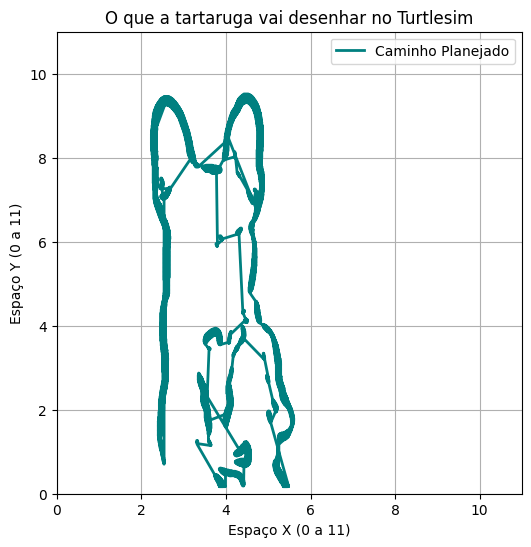

In [10]:
# Captura as dimensões reais da imagem diretamente da matriz
# altura = bordas.shape[0], largura = bordas.shape[1]
altura_real, largura_real = bordas.shape

# 1. Extrai a sequência ordenada de pixels passando largura e altura na ordem correta
caminho_pixels = extrair_caminho_ordenado(bordas, largura_real, altura_real, margem_pixels=10)

# 2. Converte essa sequência para o espaço do simulador (passando o shape correto)
caminho_final_robo = mapear_para_turtlesim(caminho_pixels, bordas.shape)

# 3. Separando os eixos X e Y para conseguir plotar
turtlesim_x = [p[0] for p in caminho_final_robo]
turtlesim_y = [p[1] for p in caminho_final_robo]

# 4. Visualização do "Simulador" no Notebook
plt.figure(figsize=(6, 6))
plt.plot(turtlesim_x, turtlesim_y, color='teal', linewidth=2, label='Caminho Planejado')
plt.title("O que a tartaruga vai desenhar no Turtlesim")
plt.xlabel("Espaço X (0 a 11)")
plt.ylabel("Espaço Y (0 a 11)")
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True)
plt.legend()
plt.show()

## 4. Controle ROS 2 (pacote)

Gera o arquivo csv do pacote para controlar os movimentos e desenhar ocontorno da imagem no Turtlesim

In [11]:
import csv
import os

pasta_projeto = r"C:\Users\Inteli\OneDrive\Área de Trabalho\TurtleDraw"
caminho_salvamento = os.path.join(pasta_projeto, "coordenadas.csv")

# O [::25] faz o Python pegar 1 ponto e pular os próximos 24.
# Teste valores entre 15 e 30. Quanto maior o número, mais rápido o robô anda,
# mas se for alto demais o desenho perde curvas acentuadas.
pontos_otimizados = caminho_final_robo[::25] 

try:
    with open(caminho_salvamento, mode='w', newline='') as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerows(pontos_otimizados)
        
    print(f"Sucesso! Reduzimos de {len(caminho_final_robo)} para {len(pontos_otimizados)} pontos!")
    print(f"Salvo em: {caminho_salvamento}")

except Exception as e:
    print(f"Erro ao salvar o arquivo: {e}")

Sucesso! Reduzimos de 25100 para 1004 pontos!
Salvo em: C:\Users\Inteli\OneDrive\Área de Trabalho\TurtleDraw\coordenadas.csv
